# Cardiac Pacemakers in Dogs with Bradyarrhythmias: Programming Parameters

Statistical analysis of ventricular impedance and stimulation thresholds over time.

**Methods Summary:**
- Descriptive statistics: median, IQR, range (non-parametric; mean $ \pm $ SD omitted - impossible negative values on raw impedance)
- Primary inference: Skillings–Mack test (Friedman generalized for unbalanced repeated measures)
- Post-hoc: Wilcoxon signed-rank (paired dogs), Holm-corrected
- Sensitivity / effect-size: linear mixed-effects model on conductance (1/impedance) with log-transformed time

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from itertools import combinations
import statsmodels.formula.api as smf
import os

os.makedirs('figuras', exist_ok=True)

IMPEDANCE_COL = 'Impedância ohms (Ω) lead status'
TIME_BINS   = [-1, 0, 7, 90, 547, 912, np.inf]
TIME_LABELS = ['T0', 'T1 (≤7d)', 'T2 (≤90d)', 'T3 (≤547d)', 'T4 (≤912d)', 'T5 (>912d)']
NUMERIC_COLS = [IMPEDANCE_COL, 'Amplit pulso', 'Duraç pulso', 'impedância Ω', 'V', 'ms']

## 2. Data Loading

In [2]:
url = 'https://raw.githubusercontent.com/caiohamamura/monica/main/PLANILHA_PM_2024.xlsx'
dados = pd.read_excel(url, sheet_name='Planilha 1 ', skiprows=1, header=0, decimal=',', engine='openpyxl')
dados.head()

,Nome,dias,Amplit pulso,Duraç pulso,Sensibilidade,Impedância ohms (Ω) lead status,V,ms,V x ms,mV,...,corrente uA,impedância Ω,Pace/Sense polarity,Margem amplitude,Marca,modelo,Diagnóstico,data implante,DIAGNÓSTICO ESTIMULAÇÃO,Unnamed: 24
0,1,0.0,3.50,0.40,2.8,950.0,0.5,0.4,0.20,NaN,...,11.26,158,BIPOLAR,2x,MEDTRONIC,Adapta ADSR01,BAVT,T0,NaN,NaN
1,1,6.0,3.50,0.46,2.8,564.0,0.5,0.46,0.23,"8 - 11,2",...,13.83,109,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T1,NaN,NaN
2,1,40.0,3.50,0.46,2,573.0,0.25,1,0.25,"5,6 - 8,0",...,13.71,110,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T2,ver stored strip p s,NaN
3,1,222.0,2.25,0.40,2,509.0,1.125,0.4,0.45,"11,2 - 15,68",...,9.99,132,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T3,NaN,NaN
4,1,908.0,2.25,0.40,2,445.0,0.75,0.4,0.30,"2,00 - 2,80",...,10.58,497,BIPOLAR,2x,MEDTRONIC,NaN,NaN,T4,ver stored strip p s,imprimir vários gráficos


## 3. Data Cleaning

In [3]:
df = dados[dados['dias'].notna()].copy()
df['dias'] = df['dias'].astype(int)
df['Nome'] = df['Nome'].astype(str)

df.loc[:, NUMERIC_COLS] = (
    df.loc[:, NUMERIC_COLS]
    .apply(lambda x: x.astype(str).str.replace(',', '.').replace(r'[^\d.]+', 'nan', regex=True))
    .astype(float)
)

df['Classe']     = pd.cut(df['dias'], TIME_BINS, labels=TIME_LABELS, include_lowest=True)
df['conductance'] = 1000 / df[IMPEDANCE_COL]
df['log_days']    = np.log1p(df['dias'])

df[['Nome', 'dias', 'Classe', IMPEDANCE_COL, 'conductance']].head(12)

,Nome,dias,Classe,Impedância ohms (Ω) lead status,conductance
0,1,0,T0,950.0,1.052632
1,1,6,T1 (≤7d),564.0,1.773050
2,1,40,T2 (≤90d),573.0,1.745201
3,1,222,T3 (≤547d),509.0,1.964637
4,1,908,T4 (≤912d),445.0,2.247191
5,1,1399,T5 (>912d),454.0,2.202643
6,2,0,T0,621.0,1.610306
7,2,7,T1 (≤7d),525.0,1.904762
8,2,43,T2 (≤90d),465.0,2.150538
9,2,287,T3 (≤547d),418.0,2.392344


## 4. Missing Data Report

In [4]:
avail = (
    df.pivot_table(index='Nome', columns='Classe', values=IMPEDANCE_COL,
                   aggfunc='count', observed=False)
      .fillna(0).astype(int)
)
print('Dog × time-band availability (1 = measured, 0 = missing):')
print(avail.to_string())
print()
print('Dogs per time point:')
print(avail.sum(axis=0).to_string())
print(f'\nTotal dogs: {df["Nome"].nunique()}   Total observations: {len(df)}')

Dog × time-band availability (1 = measured, 0 = missing):
Classe  T0  T1 (≤7d)  T2 (≤90d)  T3 (≤547d)  T4 (≤912d)  T5 (>912d)
Nome                                                               
1        1         1          1           1           1           1
10       1         1          0           1           0           0
11       1         0          0           0           0           0
2        1         1          1           1           0           0
3        1         1          0           1           0           0
4        1         1          1           0           0           0
5        1         1          1           0           0           0
6        1         1          0           1           1           1
7        1         0          1           0           0           0
8        1         0          1           0           0           0
9        1         0          1           1           0           0

Dogs per time point:
Classe
T0            11
T1 (≤7d)    

## 5. Descriptive Statistics

In [5]:
def describe_np(col):
    g = df.groupby('Classe', observed=False)[col]
    return g.agg(
        n       = 'count',
        Median  = 'median',
        Q1      = lambda x: x.quantile(.25),
        Q3      = lambda x: x.quantile(.75),
        Min     = 'min',
        Max     = 'max',
    ).round(1)

### Ventricular Impedance (Ω)

In [6]:
describe_np(IMPEDANCE_COL)

,n,Median,Q1,Q3,Min,Max
Classe,,,,,,
T0,11,702.0,642.0,787.5,507.0,2691.0
T1 (≤7d),7,564.0,521.0,701.0,472.0,1198.0
T2 (≤90d),7,565.0,526.5,572.5,465.0,832.0
T3 (≤547d),6,482.0,435.5,536.8,418.0,1084.0
T4 (≤912d),2,431.0,424.0,438.0,417.0,445.0
T5 (>912d),2,427.0,413.5,440.5,400.0,454.0


### Conductance (mS = 1000 / Ω)

Physiologically linear scale; reported alongside impedance for completeness.

In [7]:
describe_np('conductance')

,n,Median,Q1,Q3,Min,Max
Classe,,,,,,
T0,11,1.4,1.3,1.6,0.4,2.0
T1 (≤7d),7,1.8,1.5,1.9,0.8,2.1
T2 (≤90d),7,1.8,1.7,1.9,1.2,2.2
T3 (≤547d),6,2.1,1.9,2.3,0.9,2.4
T4 (≤912d),2,2.3,2.3,2.4,2.2,2.4
T5 (>912d),2,2.4,2.3,2.4,2.2,2.5


### Stimulation Threshold: Pulse Amplitude (V)

In [8]:
describe_np('Amplit pulso')

,n,Median,Q1,Q3,Min,Max
Classe,,,,,,
T0,11,3.5,3.5,5.0,3.0,5.0
T1 (≤7d),7,3.5,3.2,5.0,2.0,6.0
T2 (≤90d),7,3.5,3.0,3.8,2.0,5.0
T3 (≤547d),6,3.8,2.6,4.0,2.0,4.5
T4 (≤912d),2,2.4,2.3,2.4,2.2,2.5
T5 (>912d),2,2.1,2.1,2.2,2.0,2.2


### Battery Life: Months to ERI

In [9]:
describe_np('meses')

,n,Median,Q1,Q3,Min,Max
Classe,,,,,,
T0,11,96.0,66.0,107.0,30.0,162.0
T1 (≤7d),7,54.0,48.0,84.0,24.0,160.0
T2 (≤90d),7,90.0,82.0,100.0,66.0,120.0
T3 (≤547d),6,87.5,66.2,108.0,54.0,114.0
T4 (≤912d),2,69.0,64.5,73.5,60.0,78.0
T5 (>912d),2,51.0,49.5,52.5,48.0,54.0


## 6. Impedance Trajectory Over Time

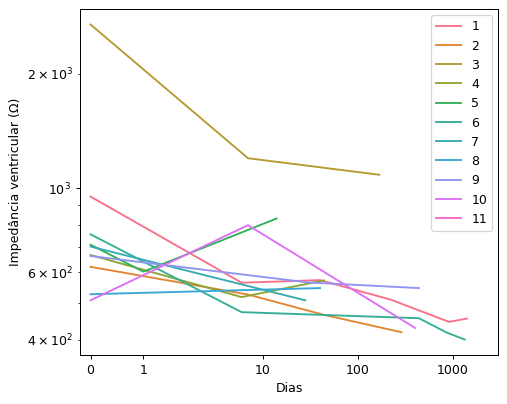

In [10]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=90)
p = sns.lineplot(data=df, x='dias', y=IMPEDANCE_COL, hue='Nome', ax=ax)
p.set_xscale('symlog')
p.set_yscale('log')
p.set_ylabel('Impedância ventricular (Ω)')
p.set_xlabel('Dias')
p.legend_.set_title('')
p.set_xlim(-0.2, 3000)
p.set_xticks([0, 1, 10, 100, 1000])
p.set_xticklabels(['0', '1', '10', '100', '1000'])
plt.savefig('figuras/Impedancia ventricular por cao.pdf')
plt.show()

## 7. Boxplot: Ventricular Impedance by Time Band

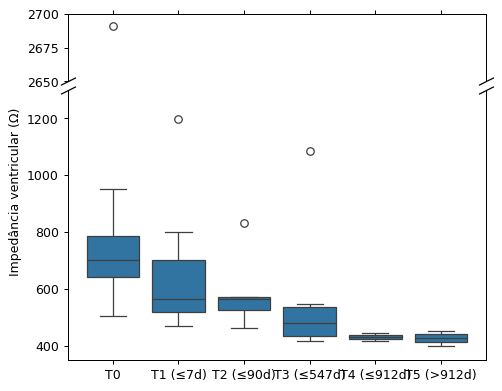

In [11]:
fig = plt.figure(figsize=(6, 5), dpi=90)
gs  = fig.add_gridspec(2, 1, height_ratios=[0.2, 0.8], hspace=0.05)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

for ax in [ax_top, ax_bot]:
    sns.boxplot(data=df, x='Classe', y=IMPEDANCE_COL, ax=ax)

ax_top.set_xlabel(''); ax_top.set_ylabel('')
ax_bot.set_xlabel('')
ax_bot.set_ylabel('Impedância ventricular (Ω)', y=0.625)
ax_top.set_ylim(2650, 2700)
ax_bot.set_ylim(350, 1300)
ax_top.spines.bottom.set_visible(False)
ax_bot.spines.top.set_visible(False)
ax_top.xaxis.tick_top()
ax_top.tick_params(labeltop=False)
ax_bot.xaxis.tick_bottom()

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax_top.plot([0, 1], [0, 0], transform=ax_top.transAxes, **kwargs)
ax_bot.plot([0, 1], [1, 1], transform=ax_bot.transAxes, **kwargs)
plt.savefig('figuras/boxplotImpedanciaVentricular.pdf')
plt.show()

## 8. Primary Analysis: Skillings–Mack Test

Generalization of the Friedman test for repeated-measures data **with missing values**.

Only 1 of 11 dogs has all 6 time points; restricting to the best 3-point window leaves 4 complete cases - insufficient. Skillings–Mack uses all available
within-dog paired information via adjusted within-block ranks, giving a χ² statistic with *(k − 1)* df.

In [12]:
def skillings_mack(wide):
    """Skillings–Mack test for repeated-measures data with missing values.
    wide : DataFrame - rows = subjects, columns = time points (NaN where missing).
    Returns (statistic, df, p_value).
    """
    M       = wide.to_numpy(dtype=float)
    n, k    = M.shape
    present = ~np.isnan(M)
    A       = np.zeros((n, k))

    for i in range(n):
        obs = np.where(present[i])[0]
        ni  = len(obs)
        if ni < 2:
            continue
        ranks      = stats.rankdata(M[i, obs])
        A[i, obs]  = np.sqrt(12.0 / (ni + 1)) * (ranks - (ni + 1) / 2.0)

    S     = A.sum(axis=0)
    Sigma = np.zeros((k, k))

    for j in range(k):
        ni_vec      = present[present[:, j]].sum(axis=1)
        Sigma[j, j] = np.sum(ni_vec - 1)
    for j, jp in combinations(range(k), 2):
        Sigma[j, jp] = Sigma[jp, j] = -(present[:, j] & present[:, jp]).sum()

    T  = float(S @ np.linalg.pinv(Sigma) @ S)
    df = k - 1
    return T, df, stats.chi2.sf(T, df)

### Helper: omnibus + post-hoc

In [13]:
def repeated_measures_np(column, label, min_n=3, min_pairs=4):
    print('=' * 60)
    print(f'OUTCOME: {label}')
    print('=' * 60)

    wide   = df.pivot_table(index='Nome', columns='Classe', values=column, observed=False)
    counts = wide.notna().sum()
    keep   = [c for c in TIME_LABELS if counts.get(c, 0) >= min_n]

    print(f'Dogs per time point: {dict(counts[TIME_LABELS].astype(int))}')
    print(f'Time points in omnibus (n ≥ {min_n}): {keep}')

    w = wide[keep]
    w = w[w.notna().sum(axis=1) >= 2]
    print(f'Dogs contributing (≥ 2 time points): {len(w)}')

    T, df_, p = skillings_mack(w)
    verdict   = 'SIGNIFICANT' if p < 0.05 else 'not significant'
    print(f'\nSkillings–Mack:  χ² = {T:.3f},  df = {df_},  p = {p:.4f}  -> {verdict}')

    if p < 0.05:
        raw = []
        for a, b in combinations(keep, 2):
            pair = wide[[a, b]].dropna()
            if len(pair) >= min_pairs:
                _, pv = stats.wilcoxon(pair[a], pair[b])
                raw.append([f'{a} vs {b}', len(pair), pv])

        order = sorted(range(len(raw)), key=lambda i: raw[i][2])
        m = len(raw); holm = [None] * m; run_max = 0
        for rank, idx in enumerate(order):
            v = min(1, (m - rank) * raw[idx][2])
            run_max = max(run_max, v)
            holm[idx] = run_max

        print('\nPost-hoc - Wilcoxon signed-rank (paired dogs), Holm-adjusted:')
        for (lab, n, pr), ph in zip(raw, holm):
            star = ' *' if ph < 0.05 else ''
            print(f'  {lab:18s}  n_pairs={n}  p_raw={pr:.4f}  p_Holm={ph:.4f}{star}')
    print()

### Ventricular Impedance

In [14]:
repeated_measures_np(IMPEDANCE_COL, 'Ventricular impedance (Ω)')

OUTCOME: Ventricular impedance (Ω)
Dogs per time point: {'T0': np.int64(11), 'T1 (≤7d)': np.int64(7), 'T2 (≤90d)': np.int64(7), 'T3 (≤547d)': np.int64(6), 'T4 (≤912d)': np.int64(2), 'T5 (>912d)': np.int64(2)}
Time points in omnibus (n ≥ 3): ['T0', 'T1 (≤7d)', 'T2 (≤90d)', 'T3 (≤547d)']
Dogs contributing (≥ 2 time points): 10

Skillings–Mack:  χ² = 12.692,  df = 3,  p = 0.0054  -> SIGNIFICANT

Post-hoc - Wilcoxon signed-rank (paired dogs), Holm-adjusted:
  T0 vs T1 (≤7d)      n_pairs=7  p_raw=0.1562  p_Holm=0.4688
  T0 vs T2 (≤90d)     n_pairs=7  p_raw=0.1562  p_Holm=0.4688
  T0 vs T3 (≤547d)    n_pairs=6  p_raw=0.0312  p_Holm=0.1562
  T1 (≤7d) vs T2 (≤90d)  n_pairs=4  p_raw=0.6250  p_Holm=0.6250
  T1 (≤7d) vs T3 (≤547d)  n_pairs=5  p_raw=0.0625  p_Holm=0.2500



### Stimulation Threshold: Pulse Amplitude

In [15]:
repeated_measures_np('Amplit pulso', 'Pulse amplitude (V)')

OUTCOME: Pulse amplitude (V)
Dogs per time point: {'T0': np.int64(11), 'T1 (≤7d)': np.int64(7), 'T2 (≤90d)': np.int64(7), 'T3 (≤547d)': np.int64(6), 'T4 (≤912d)': np.int64(2), 'T5 (>912d)': np.int64(2)}
Time points in omnibus (n ≥ 3): ['T0', 'T1 (≤7d)', 'T2 (≤90d)', 'T3 (≤547d)']
Dogs contributing (≥ 2 time points): 10

Skillings–Mack:  χ² = 4.318,  df = 3,  p = 0.2291  -> not significant



### Battery Life: Months to ERI

In [16]:
repeated_measures_np('meses', 'Battery life (months to ERI)')

OUTCOME: Battery life (months to ERI)
Dogs per time point: {'T0': np.int64(11), 'T1 (≤7d)': np.int64(7), 'T2 (≤90d)': np.int64(7), 'T3 (≤547d)': np.int64(6), 'T4 (≤912d)': np.int64(2), 'T5 (>912d)': np.int64(2)}
Time points in omnibus (n ≥ 3): ['T0', 'T1 (≤7d)', 'T2 (≤90d)', 'T3 (≤547d)']
Dogs contributing (≥ 2 time points): 10

Skillings–Mack:  χ² = 5.390,  df = 3,  p = 0.1454  -> not significant



## 9. Sensitivity Analysis: Linear Mixed-Effects Model on Conductance

**Purpose:** estimate the *magnitude* of the impedance change over time.
Raw impedance converted to **conductance (mS = 1000 / Ω)** to linearise the biological response:
while impedance scales non-linearly as peri-lead fibrosis matures, conductance scales linearly
with the cross-sectional conductive area (Ohm's Law).

**Model:** `conductance ~ log(days + 1) + (1 | dog)`

> *Sensitivity role, not primary inference:* with 11 clusters the between-dog variance is
> imprecisely estimated and the z-based p-values lack a small-sample correction. The
> Skillings–Mack test in §8 is the primary test; the mixed model quantifies effect size.
> Which resulted in significant test: $ \chi^2 $ = 12.692,  df = 3,  p = 0.0054

In [17]:
model_cond  = smf.mixedlm('conductance ~ log_days', df, groups='Nome')
result_cond = model_cond.fit(reml=False)
print(result_cond.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: conductance
No. Observations: 35      Method:             ML         
No. Groups:       11      Scale:              0.0572     
Min. group size:  1       Log-Likelihood:     -9.2238    
Max. group size:  6       Converged:          Yes        
Mean group size:  3.2                                    
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   1.395     0.111  12.579  0.000   1.177   1.612
log_days    0.108     0.018   6.101  0.000   0.074   0.143
Nome Var    0.093     0.241                               



### Fixed Effects Summary

In [18]:
fe = result_cond.fe_params
se = result_cond.bse_fe
z  = result_cond.tvalues
p  = result_cond.pvalues
ci = result_cond.conf_int()

fe_table = pd.DataFrame({
    'Estimate':     fe,
    'Std.Error':    se,
    'z':            z,
    'P>|z|':        p,
    '95% CI Lower': ci[0],
    '95% CI Upper': ci[1],
})
fe_table.iloc[[0, 1]]

,Estimate,Std.Error,z,P>|z|,95% CI Lower,95% CI Upper
Intercept,1.394723,0.110875,12.579240,2.746606e-36,1.177412,1.612034
Nome Var,NaN,NaN,1.609186,1.075758e-01,-0.353315,3.594961


### Back-transformed interpretation

The slope is expressed in mS per log-day unit, which is not clinically intuitive.
We will convert model trajectory back to impedance (Ω) at key time points.

In [19]:
slope_ci = result_cond.conf_int().loc['log_days']
slope_ci

,log_days
0,0.073596
1,0.143261


In [29]:
intercept = result_cond.fe_params['Intercept']
slope     = result_cond.fe_params['log_days']
cov_fe    = result_cond.cov_params().loc[['Intercept', 'log_days'], ['Intercept', 'log_days']].values

checkpoints = {'T0 (day 0)': 0, 'T1 (day 3.5)': 3.5, 'T2 (day 45)': 45, 'T3 (day 273.5)': 273.5}
print('Model-predicted trajectory (population mean):')
print(f'  {"Time point":<16}  {"Conductance (mS) [95% CI]":>31}  {"Impedance (Ω) [95% CI]":>29}')
print('  ' + '-' * 85)
for label, day in checkpoints.items():
    g  = np.array([1.0, np.log1p(day)])
    cond_hat = g @ np.array([intercept, slope])
    se       = np.sqrt(g @ cov_fe @ g)
    cond_hat_lower = cond_hat - 1.96 * se
    cond_hat_upper = cond_hat + 1.96 * se
    imp_hat        = 1000 / cond_hat
    imp_hat_lower  = 1000 / cond_hat_upper   # monotonic decreasing -> bounds swap
    imp_hat_upper  = 1000 / cond_hat_lower
    print(f'  {label:<16}  {cond_hat:>16.3f} [{cond_hat_lower:.3f}, {cond_hat_upper:>.3f}]  {imp_hat:>14.1f} [{imp_hat_lower:>.1f}, {imp_hat_upper:>.1f}]')

Model-predicted trajectory (population mean):
  Time point              Conductance (mS) [95% CI]         Impedance (Ω) [95% CI]
  -------------------------------------------------------------------------------------
  T0 (day 0)                   1.395 [1.177, 1.612]           717.0 [620.3, 849.3]
  T1 (day 3.5)                 1.558 [1.356, 1.760]           641.9 [568.2, 737.7]
  T2 (day 45)                  1.810 [1.605, 2.015]           552.5 [496.4, 623.0]
  T3 (day 273.5)               2.004 [1.776, 2.231]           499.1 [448.3, 563.0]


### Model Diagnostics

Assumptions checked on **residuals** (not raw data):
1. Normality of residuals (Q-Q plot + Shapiro-Wilk)
2. Homoscedasticity (residuals vs fitted values)

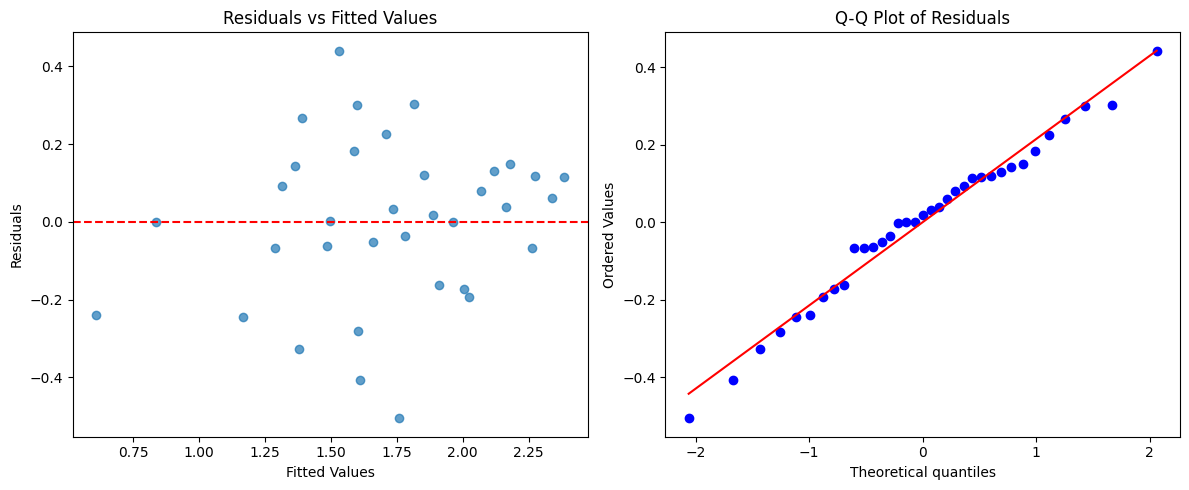

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(result_cond.fittedvalues, result_cond.resid, alpha=0.7)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted Values')

stats.probplot(result_cond.resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.savefig('figuras/mixed_model_diagnostics_conductance.pdf')
plt.show()

In [22]:
stat, p = stats.shapiro(result_cond.resid)
print(f'Shapiro-Wilk on residuals: W={stat:.3f}, p={p:.3f}')
print(f'  -> Residuals are {"normally" if p > 0.05 else "not normally"} distributed (p {">" if p > 0.05 else "<="} 0.05)')

Shapiro-Wilk on residuals: W=0.983, p=0.850
  -> Residuals are normally distributed (p > 0.05)


### Per-Dog Random Intercepts (BLUPs)

Best Linear Unbiased Predictors - how each dog's baseline conductance deviates from the population mean.

-----------
-- BLUPs --
-----------
 intercept dog_id
 -0.784365      3
 -0.107437     11
 -0.078576      5
 -0.029387      9
 -0.016180      1
  0.092600      7
  0.103353      4
  0.137039     10
  0.206551      8
  0.210157      6
  0.266245      2


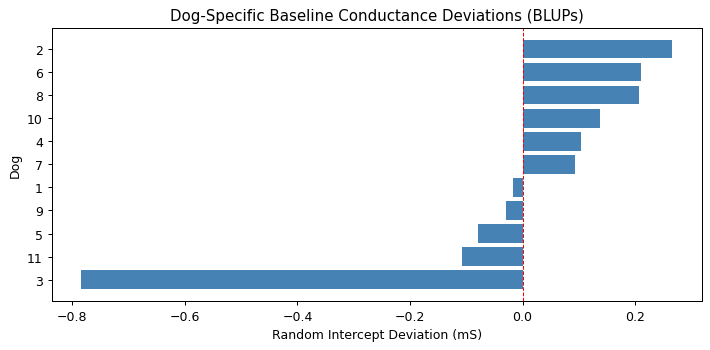

In [23]:
individual_intercepts = {
    group: effects['Nome']
    for group, effects in result_cond.random_effects.items()
}

s = pd.DataFrame({
    'intercept': individual_intercepts.values(),
    'dog_id':    individual_intercepts.keys(),
}).sort_values('intercept')

print('-----------')
print('-- BLUPs --')
print('-----------')
print(s.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4), dpi=90)
ax.barh(s['dog_id'], s['intercept'], color='steelblue')
ax.axvline(0, linestyle='--', color='red', linewidth=0.8)
ax.set_xlabel('Random Intercept Deviation (mS)')
ax.set_ylabel('Dog')
ax.set_title('Dog-Specific Baseline Conductance Deviations (BLUPs)')
plt.tight_layout()
plt.savefig('figuras/random_intercepts_bar_conductance.pdf')
plt.show()